## Business Problem

* A global E-commerce company operating across multiple region manages end-to-end order fullfillment, including shipping and delivvery, for products like sporting gooda. The company is facing inconsistent delivery performance, where actual shipping times often deviate from scheduled timelines, leading to late deliveries and unpredictable order profitability


### Desired Outcome:

* The goal is to analyze delivery operation, identify bottlenecks, and builed a predictive system to reduce delays, optimize shipping decision, and improve overall profitability snd efficiency.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings("ignore")
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [2]:
df = pd.read_csv("data/SupplyChainDataset.csv", encoding='latin-1')


FileNotFoundError: [Errno 2] No such file or directory: 'data/SupplyChainDataset.csv'

In [ ]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.09,311.36,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.78,309.72,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.86,304.81,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.21,298.25,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [ ]:
print('Rows, Columns:', df.shape)
print('\nColumns')
print(df.columns)
print('\nNum Duplicates:', df.duplicated().sum())
print('\nMissing values (top 3):')
print(df.isnull().sum().sort_values(ascending=False).head(3))

Rows, Columns: (180519, 53)

Columns
Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Pro

In [ ]:
'Order City', 'Order Country','Order State',

('Order City', 'Order Country', 'Order State')

In [ ]:
df.shape

(180519, 53)

In [ ]:
columns_to_drop = [
    
    'Benefit per order',
    
    'Category Id',
    'Customer Email',
    'Customer Password',
    'Customer Fname', 
    'Customer Lname', 
    'Customer Street', 
    'Customer Zipcode',
    'Customer Id',
    'Customer State',
    'Customer City',
    'Customer City',
    
    
    'Department Id',

    'Latitude',
    'Longitude',
    
    'Order Zipcode',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Item Total',
    'Order Id',
    'Order Customer Id',
    'Order City',
    'Order Country',
    'Order State',
    
    
    'Product Description',
    'Product Image',
    'Product Card Id',
    'Product Category Id',
    'Product Status',
    
    

    'Market']

In [ ]:
# 1. Columns drop karne ke liye (errors='ignore' lagaya hai taaki error na aaye)
df.drop(columns=columns_to_drop, errors='ignore', inplace=True)

# 2. Shipping filter karne ke liye
df = df[df['Delivery Status'] != 'Shipping canceled']

# 3. Date convert karne ke liye
for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
    df[c] = pd.to_datetime(df[c], errors='coerce', dayfirst=False)
    
# 4. Output check karne ke liye
print('Rows, Columns:', df.shape)
print('\nMissing values (top 3):')
print(df.isnull().sum().sort_values(ascending=False).head(3))

Rows, Columns: (172765, 20)

Missing values (top 3):
Type                          0
Days for shipping (real)      0
shipping date (DateOrders)    0
dtype: int64


In [ ]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.64,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-31 22:56:00,0.29,327.75,91.25,Southeast Asia,COMPLETE,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.36,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-13 12:27:00,-0.80,327.75,-249.09,South Asia,PENDING,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.72,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,2018-01-13 12:06:00,-0.80,327.75,-247.78,South Asia,CLOSED,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.81,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,2018-01-13 11:45:00,0.08,327.75,22.86,Oceania,COMPLETE,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.25,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,2018-01-13 11:24:00,0.45,327.75,134.21,Oceania,PENDING_PAYMENT,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


In [ ]:
for col in df.columns:
    if df[col].nunique() < 10:
        print(f'\n{col} value counts:')
        print(df[col].value_counts())


Type value counts:
Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real) value counts:
Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64

Days for shipment (scheduled) value counts:
Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64

Delivery Status value counts:
Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

Late_delivery_risk value counts:
Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

Customer Country value counts:
Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

Customer Segment value counts:
Customer Segment
Consumer       89420
Corporate      52528
Home Office    30817
Name: count, dtype: int64

Order Status value counts:
Order Status
COMPLETE  

In [ ]:
# calculating order processing time in delay

df['Order Processing Time'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days
df['Delay'] = df['Order Processing Time'] - df['Days for shipment (scheduled)']
df['Is_Delayed'] = df['Delay'] > 0
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_day'] = df['order date (DateOrders)'].dt.day_name()
df['order_hour'] = df['order date (DateOrders)'].dt.hour
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order Processing Time,Delay,order_month,order_hour
count,172765.00,172765.00,172765.00,172765.00,172765,172765.00,172765.00,172765.00,172765.00,172765,172765.00,172765.00,172765.00,172765.00
mean,3.50,2.93,183.17,0.57,2016-06-12 15:25:39.457991,0.12,203.83,22.03,141.28,2016-06-16 03:25:14.452927,3.47,0.54,6.24,11.48
min,0.00,0.00,7.49,0.00,2015-01-01 00:00:00,-2.75,9.99,-4274.98,9.99,2015-01-03 00:00:00,0.00,-2.00,1.00,0.00
25%,2.00,2.00,104.38,0.00,2015-09-21 18:01:00,0.08,119.98,7.03,50.00,2015-09-25 08:59:00,2.00,0.00,3.00,5.00
50%,3.00,4.00,163.99,1.00,2016-06-11 08:11:00,0.27,199.92,31.52,59.99,2016-06-15 03:38:00,3.00,1.00,6.00,11.00
75%,5.00,4.00,247.40,1.00,2017-02-28 21:08:00,0.36,299.95,64.80,199.99,2017-03-04 08:00:00,5.00,1.00,9.00,17.00
max,6.00,4.00,1939.99,1.00,2018-01-31 23:38:00,0.50,1999.99,911.80,1999.99,2018-02-06 22:14:00,6.00,4.00,12.00,23.00
std,1.62,1.37,120.14,0.49,NaN,0.47,132.39,104.36,139.86,NaN,1.67,1.49,3.41,6.93


In [ ]:
df['Is_Delayed'].value_counts()

Is_Delayed
True     94523
False    78242
Name: count, dtype: int64

In [ ]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'Order Processing Time', 'Delay', 'Is_Delayed',
       'order_month', 'order_day', 'order_hour'],
      dtype='str')

In [ ]:
df['Profitability Flag'] = np.where(df['Order Profit Per Order'] > 0, 'Profit', np.where(df['Order Profit Per Order'] < 0, 'Loss', 'Break-even'))
df['Profitability Flag'].value_counts()

Profitability Flag
Profit        139354
Loss           32295
Break-even      1116
Name: count, dtype: int64

In [ ]:
df['Profitability Flag'].value_counts(normalize=True) * 100

Profitability Flag
Profit       80.66
Loss         18.69
Break-even    0.65
Name: proportion, dtype: float64

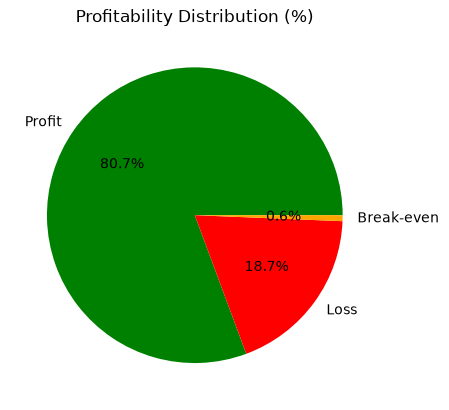

In [ ]:
# visualization of the profitability Distribution

profit_counts = df['Profitability Flag'].value_counts(normalize=True) * 100
profit_counts.plot(kind='pie', autopct='%1.1f%%', colors=['green', 'red', 'orange'])
plt.title('Profitability Distribution (%)')
plt.show()

In [ ]:
def format_fun(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'
    
    
delayed_df = df[df['Delay'] > 0]
metrics = {}
metrics['Total Orders'] = len(df)
metrics['Late Deliveries'] = len(delayed_df)
metrics['90% Delay (days)'] = delayed_df['Delay'].quantile(0.90)
metrics['On time Delivery %'] = (1-float(metrics['Late Deliveries'])/metrics['Total Orders'])*100
metrics['Late Delivery %'] = float(metrics['Late Deliveries'])/metrics['Total Orders']*100
metrics['Total profit'] = format_fun(df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order'].sum())
metrics['Total loss due to delays'] = format_fun(df.loc[df['Delay'] > 0, 'Order Profit Per Order'].sum())

print('\n--- Business KPIs ---\n')
for k, v in metrics.items():
    if isinstance(v, float):
        print(f'{k}: {v:.2f}')
    else:
        print(f'{k}: {v}')




--- Business KPIs ---

Total Orders: 172765
Late Deliveries: 94523
90% Delay (days): 3.00
On time Delivery %: 45.29
Late Delivery %: 54.71
Total profit: 7.5M $
Total loss due to delays: 2.1M $


# Profitability vs Delivery Time Analysis

In [ ]:
profit_metrics = (
    df.groupby('Delay')['Order Profit Per Order']
    .agg(
        mean_profit = 'mean',
        total_profit = 'sum',
        count_orders = 'count'
    )
    .reset_index()
)

In [ ]:
profit_metrics

,Delay,mean_profit,total_profit,count_orders
0,-2,23.36,487596.07,20873
1,-1,21.60,447629.21,20719
2,0,22.25,815430.19,36650
3,1,22.33,1194894.65,53503
4,2,21.13,582111.05,27551
5,3,20.03,135652.72,6772
6,4,21.37,143106.74,6697


In [ ]:
delay_distribution = (
    df['Delay']
    .value_counts(normalize=True)
    .sort_index() * 100
).reset_index()

In [ ]:
delay_distribution

,Delay,proportion
0,-2,12.08
1,-1,11.99
2,0,21.21
3,1,30.97
4,2,15.95
5,3,3.92
6,4,3.88


In [ ]:
profit_metrics.head(1)

,Delay,mean_profit,total_profit,count_orders
0,-2,23.36,487596.07,20873



Profit Metrics by Delay Day : 


,Delay,mean_profit,total_profit,count_orders
0,-2,23.00,487596.00,20873
1,-1,22.00,447629.00,20719
2,0,22.00,815430.00,36650
3,1,22.00,1194895.00,53503
4,2,21.00,582111.00,27551
5,3,20.00,135653.00,6772
6,4,21.00,143107.00,6697



Delay Distribution (%):


,Delay_Days,Percentage
0,-2,12.08
1,-1,11.99
2,0,21.21
3,1,30.97
4,2,15.95
5,3,3.92
6,4,3.88


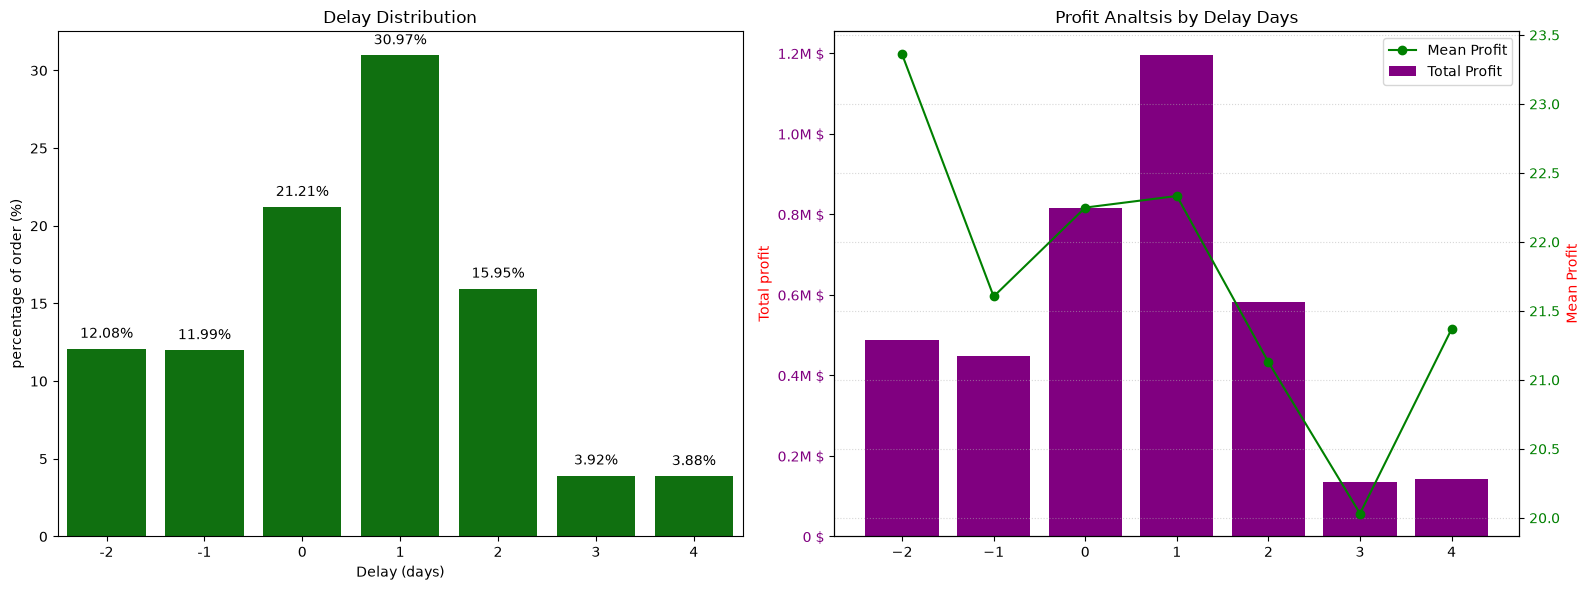

In [ ]:
delay_distribution.columns = ['Delay_Days', 'Percentage']
delay_distribution['Percentage']= delay_distribution['Percentage'].round(2)

print('\nProfit Metrics by Delay Day : ')
display(profit_metrics.round())

print('\nDelay Distribution (%):')
display(delay_distribution)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (16, 6))

# First subplot: Delay Distribution
sns.barplot(x='Delay_Days', y=delay_distribution['Percentage'], data = delay_distribution, color='green', ax=ax1)
ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (days)')
ax1.set_ylabel('percentage of order (%)')

# percentage text on bars
for bar in ax1.patches:
    height = bar.get_height()
    # ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:2f}%', ha= 'center', va='bottom')
    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.2f}'.rstrip('0').rstrip('.') + '%', ha= 'center', va='bottom')
    
    
    
# Second subplot: Profit Analysis by Delay Days
ax2.set_ylabel('Total profit', color = 'red')
ax2.bar(profit_metrics['Delay'], profit_metrics['total_profit'], color = 'purple', label='Total Profit')
ax2.tick_params(axis='y', labelcolor= 'purple')

ax3 = ax2.twinx()

ax3.set_xlabel("Delay Days")
ax3.set_ylabel("Mean Profit", color = 'red')
ax3.plot(profit_metrics['Delay'], profit_metrics['mean_profit'], marker='o', label='Mean Profit', color = 'green')
ax3.tick_params(axis='y', labelcolor = 'green')


# Formate total profit axis to K $, M $
def format_func(value, tick_number):
    if value >= 126:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/le3:.1f}K $'
    else:
        return f'{value:.0f} $'
    
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(format_func))
   
ax3.set_title('Profit Analtsis by Delay Days')

lines, labels = ax3.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax3.legend(lines + lines2, labels + labels2, loc = 'upper right')
ax3.grid(True, linestyle= ':', alpha=0.5)

plt.tight_layout()
plt.show()


# Bottleneck Detection

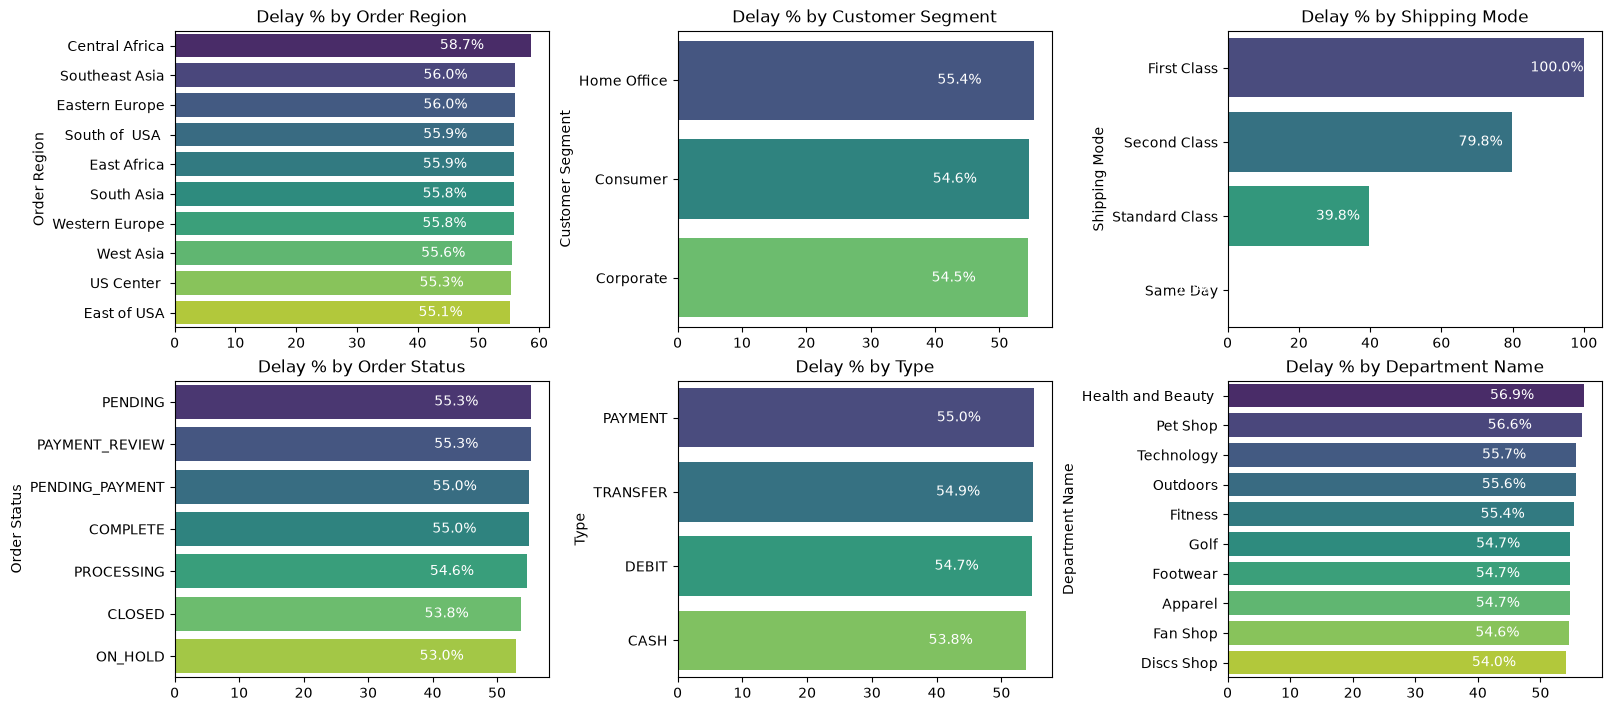

In [ ]:
def compute_delay_pct_by_category(category):
    cat_df = df.groupby(category).agg(
        total_orders = ('Delay', 'count'),
        late_orders = ('Is_Delayed', 'sum')
    ).reset_index()
    cat_df['delay_pct'] = cat_df['late_orders'] / cat_df['total_orders'] * 100
    cat_df = cat_df.sort_values('delay_pct', ascending=False).head(10)
    return cat_df

categories = ['Order Region', 'Customer Segment', 'Shipping Mode', 'Order Status', 'Type', 'Department Name']

fig, axes = plt.subplots(2, 3, figsize=(16, 7), constrained_layout=True)
axes = axes.flatten()

for ax, category in zip(axes, categories):
    cat_df = compute_delay_pct_by_category(category=category)
    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category,
        ax=ax,
        palette='viridis'
    )
    ax.set_title(f'Delay % by {category}')
    ax.set_xlabel('')
    ax.set_ylabel(category)
    for i, row in cat_df.reset_index().iterrows():
        ax.text(row['delay_pct'] - 15, i, f"{row['delay_pct']:.1f}%", va='center', fontsize=10, color='white')
        
plt.show()

# Root Cause Analycic


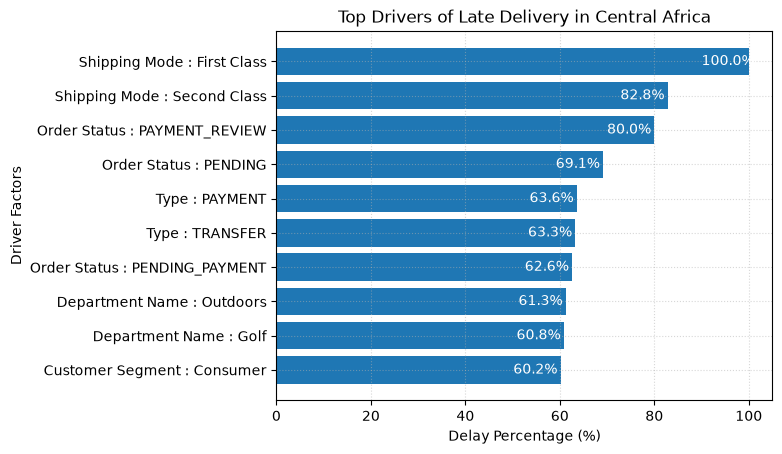

In [ ]:
# top drivers of late delivery by region

def top_drivers_for_region(region):
    df_region = df[df['Order Region'] == region].copy()
    
    drivers = ['Shipping Mode', 'Customer Segment', 'Department Name','Type', 'Order Status']
    
    all_factors = []
    for factor in drivers:
        temp = (
            df_region.groupby(factor)
            .agg(total_orders = ('Delay', 'count'),
                late_orders = ('Is_Delayed', 'sum'),
                avg_delay = ('Delay', 'mean')
            )
            .reset_index()
        )
        
        temp['delay_pct'] = temp['late_orders'] / temp['total_orders'] * 100
        temp['Driver'] = factor
        temp['Factor_Level'] = factor + " : " + temp[factor].astype(str)
        
        all_factors.append(temp[['Driver', 'Factor_Level', 'delay_pct', 'avg_delay', 'total_orders']])
        
    # Combine all drivers
    final_df = pd.concat(all_factors)
    
    # Top 10 drivers
    
    top_factors = final_df.sort_values('delay_pct', ascending=False).head(10)
    plt.figure()
    
    bars = plt.barh(top_factors['Factor_Level'], top_factors['delay_pct'])
    
    plt.xlabel("Delay Percentage (%)")
    plt.ylabel("Driver Factors")
    plt.title(f"Top Drivers of Late Delivery in {region}")
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.gca().invert_yaxis()
    for bar in bars:
        width = bar.get_width()
        plt.text(width - 10, bar.get_y() + bar.get_height()/2,
            f"{width:.1f}%",
            va = 'center', fontsize = 10, color = 'white'
            
            )
    
    plt.show()
    
top_drivers_for_region('Central Africa')

# Time-Based Analysis

In [ ]:
# Delay % by Month, Day of week, Hour

delay_by_month=(
    df.groupby('order_month')['Is_Delayed']
        .mean()
        .reset_index()
)
delay_by_month['delay_pct'] = delay_by_month['Is_Delayed'] * 100

delay_by_day = (
    df.groupby('order_day')['Is_Delayed']
        .mean()
        .reset_index()
)
delay_by_day['delay_pct'] = delay_by_day['Is_Delayed'] * 100

delay_by_hour = (
    df.groupby  ('order_hour')['Is_Delayed']
        .mean()
        .reset_index()
)
delay_by_hour['delay_pct'] = delay_by_hour['Is_Delayed'] * 100

In [ ]:
delay_by_month.head()

,order_month,Is_Delayed,delay_pct
0,1,0.54,54.25
1,2,0.55,54.60
2,3,0.55,54.81
3,4,0.55,54.50
4,5,0.55,55.00


In [ ]:
delay_by_day.head()

,order_day,Is_Delayed,delay_pct
0,Friday,0.54,54.49
1,Monday,0.56,55.53
2,Saturday,0.54,54.26
3,Sunday,0.55,55.15
4,Thursday,0.55,54.72


In [ ]:
delay_by_hour.head()

,order_hour,Is_Delayed,delay_pct
0,0,0.54,54.07
1,1,0.55,55.42
2,2,0.55,55.19
3,3,0.54,54.14
4,4,0.54,53.67


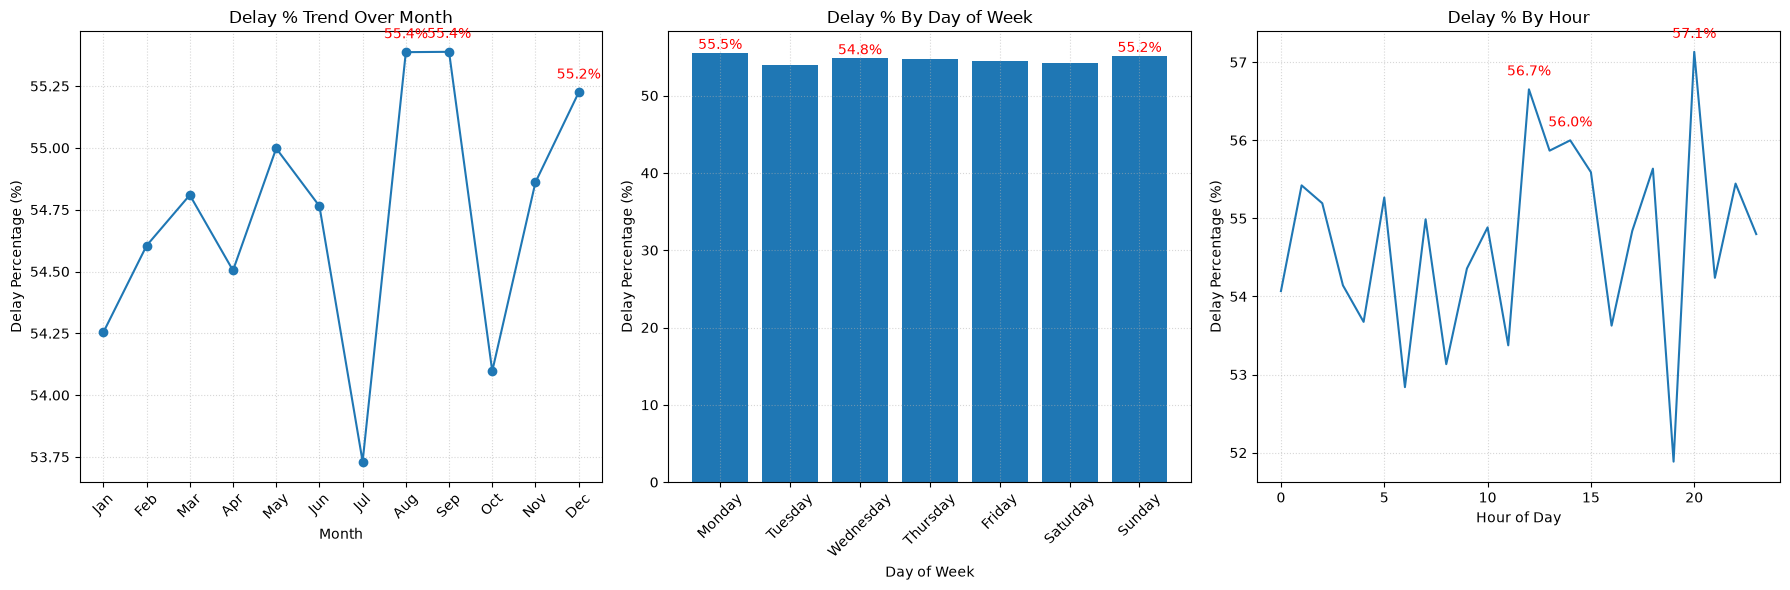

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. 'subplots' (with 's') aur figsize ko sahi se likha
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# --- Subplot 1: Delay % Trend Over Month ---
# Brackets ko sahi kiya yahan
ax1.plot(delay_by_month['order_month'], delay_by_month['delay_pct'], marker='o', color="#1f77b4") 
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
ax1.set_xlabel('Month')
ax1.set_ylabel('Delay Percentage (%)')
ax1.set_title('Delay % Trend Over Month')
ax1.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest
top3_month = delay_by_month.nlargest(3, 'delay_pct')
for _, row in top3_month.iterrows():
    ax1.annotate(f"{row['delay_pct']:.1f}%", (row['order_month'], row['delay_pct']),
                 textcoords='offset points', xytext=(0, 10), ha='center', fontsize=10, color='red')
    
# --- Subplot 2: Delay % by Day of Week ---
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
# Yahan column name 'order_day' sahi kiya
delay_by_day['order_day'] = pd.Categorical(delay_by_day['order_day'], categories=day_order, ordered=True)
delay_by_day = delay_by_day.sort_values('order_day')

ax2.bar(delay_by_day['order_day'], delay_by_day['delay_pct'], color="#1f77b4")
ax2.set_xticklabels(delay_by_day['order_day'], rotation=45) # 'order' ko 'order_day' kiya
ax2.set_xlabel('Day of Week')
ax2.set_ylabel('Delay Percentage (%)')
ax2.set_title('Delay % By Day of Week')
ax2.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest bars
top3_day = delay_by_day.nlargest(3, 'delay_pct')
for _, row in top3_day.iterrows():
    height = row['delay_pct']
    # Text positioning aur string formatting ko sahi kiya
    ax2.text(row['order_day'], height + 0.5, f"{height:.1f}%", ha='center', fontsize=10, color='red')
    
# --- Subplot 3: Delay % By Hour ---
ax3.plot(delay_by_hour['order_hour'], delay_by_hour['delay_pct'], color="#1f77b4")
ax3.set_xlabel('Hour of Day')
ax3.set_ylabel('Delay Percentage (%)')
ax3.set_title('Delay % By Hour')
ax3.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest
top3_hour = delay_by_hour.nlargest(3, 'delay_pct')
for _, row in top3_hour.iterrows():
    ax3.annotate(f"{row['delay_pct']:.1f}%", (row['order_hour'], row['delay_pct']),
                 textcoords='offset points', xytext=(0, 10), ha='center', fontsize=10, color='red')
    
plt.tight_layout()
plt.show() # 'pplt' ko 'plt' kiya

# Machine Learning Modeling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from collections import Counter
from imblearn.over_sampling import SMOTE


In [ ]:
X = [['Type', 'Days for shipment (scheduled)', 'Category Name', 'Customer Segment', 'Department Name', 'Order Region', 'Shipping Mode', 'order_month', 'order_hour']]

y = df['Late_delivery_risk']

In [ ]:
from sklearn.model_selection import train_test_split

# Features
X = df[
    [
        'Type',
        'Days for shipment (scheduled)',
        'Category Name',
        'Customer Segment',
        'Department Name',
        'Order Region',
        'Shipping Mode',
        'order_month',
        'order_hour'
    ]
].copy()

# Target
y = df['Late_delivery_risk']

# Find categorical columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical Columns:", cat_cols)

# Frequency Encoding
for col in cat_cols:
    freq = X[col].value_counts(normalize=True)
    X[f'{col}_freq'] = X[col].map(freq)

# Drop original categorical columns
X_encoded = X.drop(columns=cat_cols)

print("Shape after encoding:", X_encoded.shape)

# Final features
X = X_encoded

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Categorical Columns: ['Type', 'Category Name', 'Customer Segment', 'Department Name', 'Order Region', 'Shipping Mode']
Shape after encoding: (172765, 9)


In [ ]:
y.value_counts()

Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

In [ ]:
# Balancing the training data using SMOTE
print("Before balancing (train):", Counter(y_train))

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("After balancing (train):", Counter(y_train_bal))

Before balancing (train): Counter({1: 79182, 0: 59030})
After balancing (train): Counter({0: 79182, 1: 79182})


In [ ]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n--- {model_name} ---")
    print("\nAccuracy :", round(accuracy_score(y_true, y_pred), 2))
    print("\nPrecision :", round(precision_score(y_true, y_pred), 2))
    print("\nRecall :", round(recall_score(y_true, y_pred), 2))
    print("\nClassification Report :\n", classification_report(y_true, y_pred))

In [ ]:
# Fit the Random Forest model on balanced data

rf_model_balanced = RandomForestClassifier(random_state=42)
rf_model_balanced.fit(X_train_bal, y_train_bal)

y_pred_rf_balanced = rf_model_balanced.predict(X_test)

evaluate_model(y_test, y_pred_rf_balanced, "Random Forest Classifier")


--- Random Forest Classifier ---

Accuracy : 0.74

Precision : 0.78

Recall : 0.75

Classification Report :
               precision    recall  f1-score   support

           0       0.68      0.72      0.70     14758
           1       0.78      0.75      0.77     19795

    accuracy                           0.74     34553
   macro avg       0.73      0.74      0.73     34553
weighted avg       0.74      0.74      0.74     34553



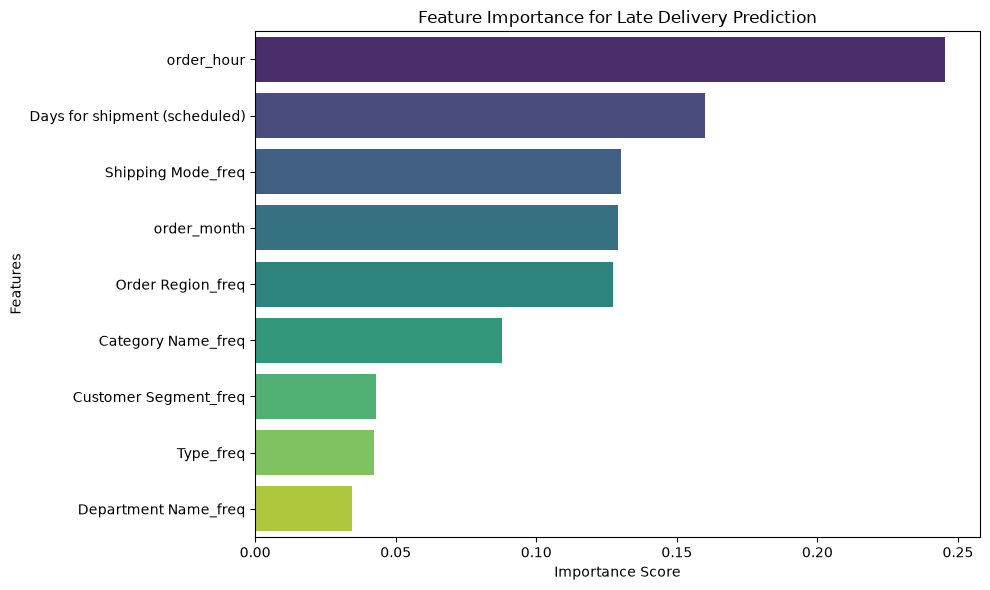

Model aur Frequency Encodings successfully save ho gaye hain!


In [ ]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Plotting Feature Importance
feature_importances = pd.DataFrame({
    'Feature': X_train_bal.columns,
    'Importance': rf_model_balanced.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances, x='Importance', y='Feature', palette='viridis')
plt.title("Feature Importance for Late Delivery Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# 2. Saving the Model and Frequency Mappings for Streamlit
# Original DataFrame (df) se frequency mappings nikal kar save kar rahe hain
cat_cols = ['Type', 'Category Name', 'Customer Segment', 'Department Name', 'Order Region', 'Shipping Mode']
freq_mappings = {}

for col in cat_cols:
    freq_mappings[col] = df[col].value_counts(normalize=True).to_dict()

# Model aur Mappings ko save karna
joblib.dump(rf_model_balanced, 'model/rf_late_delivery_model.pkl')
joblib.dump(freq_mappings, 'model/freq_mappings.pkl')

print("Model aur Frequency Encodings successfully save ho gaye hain!")